# Designing a low-Reynolds-number airfoil for your mission

This tutorial designs a **robust, multi-objective** airfoil with
[AeroSandbox](https://github.com/peterdsharpe/AeroSandbox) +
[NeuralFoil](https://github.com/peterdsharpe/NeuralFoil) — fast enough to run on
a laptop, no CFD license needed.

You describe a *mission* (Reynolds/AoA envelope + what you care about) and the
tool returns a section that performs well across the **whole** envelope, not just
one point. Useful for small UAVs, distributed wind turbines, and other low-Re
lifting surfaces.

**Setup:** `pip install -r requirements.txt`

In [1]:
import numpy as np, matplotlib.pyplot as plt
import airfoil_designer as ad   # the design tool in this repo


## 1. Describe your mission

Every design choice is a config field — no code edits. Here we use a small,
fast envelope so the notebook runs in a few seconds; bump `n_Re`/`n_AoA` and turn
on `manufacturing`/`validate_xfoil` for production runs (see `configs/`).

In [2]:
import yaml, tempfile, os

mission = {
    "name": "tutorial_uav",
    "model": "large",
    "envelope": {"Re": [80e3, 400e3], "AoA": [0, 8], "n_Re": 3, "n_AoA": 3},
    "design_point": {"Re": 200e3, "AoA": 4},
    "objectives": {                 # the dial — relative importance
        "efficiency": 1.0,          #   worst-case L/D (range/endurance)
        "safety":     0.5,          #   gentle, late stall
        "structure":  0.3,          #   spar depth
        "noise":      0.5,          #   quiet trailing edge
    },
    "constraints": {"thickness": [0.09, 0.15]},
    "manufacturing": {"enabled": False},   # set True for field-built wings
    "validate_xfoil": False,               # set True if an xfoil binary is on PATH
}

# Write to YAML and load through the tool's normalizer (fills defaults / casts).
p = os.path.join(tempfile.mkdtemp(), "tutorial_uav.yaml")
yaml.safe_dump(mission, open(p, "w"))
cfg = ad.load_config(p)
print("mission:", cfg["name"], "| objectives:", cfg["objectives"])


mission: tutorial_uav | objectives: {'efficiency': 1.0, 'noise': 0.5, 'safety': 0.5, 'structure': 0.3}


## 2. Design the airfoil

`ad.design` runs a gradient-based, multi-start optimization: it maximizes the
worst-case L/D over the envelope (an epigraph max-min) plus the weighted
safety/structure/noise terms, from several seed shapes, keeping the best.

In [3]:
af = ad.design(cfg)
print(f"max thickness = {af.max_thickness()*100:.1f}% chord")


max thickness = 9.0% chord


## 3. Evaluate across the envelope

In [4]:
df = ad.evaluate(af, cfg)
print(f"worst-case L/D = {df.L_over_D.min():.1f}")
print(f"mean L/D       = {df.L_over_D.mean():.1f}")
print(f"peak L/D       = {df.L_over_D.max():.1f}")
df.head()


worst-case L/D = 53.1
mean L/D       = 81.0
peak L/D       = 119.3


/Users/neelmadhav/Airfoil research/.venv/lib/python3.9/site-packages/neuralfoil/main.py:227: RuntimeWarning: divide by zero encountered in matmul
  x = w @ x + np.reshape(b, (-1, 1))
/Users/neelmadhav/Airfoil research/.venv/lib/python3.9/site-packages/neuralfoil/main.py:227: RuntimeWarning: overflow encountered in matmul
  x = w @ x + np.reshape(b, (-1, 1))
/Users/neelmadhav/Airfoil research/.venv/lib/python3.9/site-packages/neuralfoil/main.py:227: RuntimeWarning: invalid value encountered in matmul
  x = w @ x + np.reshape(b, (-1, 1))
/Users/neelmadhav/Airfoil research/.venv/lib/python3.9/site-packages/neuralfoil/main.py:63: RuntimeWarning: divide by zero encountered in matmul
  return np.sum(x_minus_mean @ d["inv_cov_inputs_scaled"] * x_minus_mean, axis=1)
/Users/neelmadhav/Airfoil research/.venv/lib/python3.9/site-packages/neuralfoil/main.py:63: RuntimeWarning: overflow encountered in matmul
  return np.sum(x_minus_mean @ d["inv_cov_inputs_scaled"] * x_minus_mean, axis=1)
/Users/nee

,Re,AoA,CL,CD,L_over_D,analysis_confidence
0,80000.0,0.0,1.026952,0.019339,53.102580,0.926866
1,80000.0,1.0,1.122078,0.021064,53.268781,0.944631
2,80000.0,2.0,1.208656,0.022315,54.163333,0.958725
3,80000.0,3.0,1.313500,0.024608,53.377670,0.969150
4,80000.0,4.0,1.416405,0.026673,53.102580,0.972176


## 4. Look at the shape and the L/D map

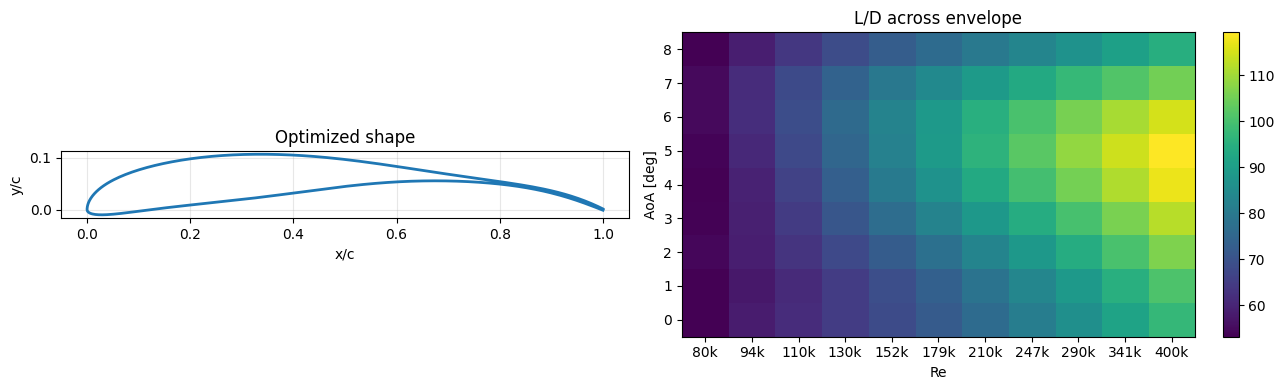

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

co = af.coordinates
ax1.plot(co[:, 0], co[:, 1], lw=2)
ax1.set_aspect("equal"); ax1.grid(alpha=0.3)
ax1.set_title("Optimized shape"); ax1.set_xlabel("x/c"); ax1.set_ylabel("y/c")

piv = df.pivot_table(index="AoA", columns="Re", values="L_over_D")
im = ax2.imshow(piv.values, origin="lower", aspect="auto", cmap="viridis",
                extent=[0, len(piv.columns), 0, len(piv.index)])
ax2.set_xticks(np.arange(len(piv.columns)) + 0.5)
ax2.set_xticklabels([f"{x/1e3:.0f}k" for x in piv.columns])
ax2.set_yticks(np.arange(len(piv.index)) + 0.5)
ax2.set_yticklabels([f"{y:.0f}" for y in piv.index])
ax2.set_xlabel("Re"); ax2.set_ylabel("AoA [deg]"); ax2.set_title("L/D across envelope")
fig.colorbar(im, ax=ax2, fraction=0.046)
plt.tight_layout(); plt.show()


## 5. Make it your own

- **Change the dial.** Crank `safety`/`noise` for a vehicle that overflies people;
  crank `structure` and raise the thickness band for a load-bearing blade.
- **Robust to build error.** Set `manufacturing: {enabled: true, sigma_weight: 0.04}`
  to design for ~0.5%-chord surface error (field-built / 3D-printed wings).
- **Validate.** With an `xfoil` binary on PATH, set `validate_xfoil: true` for an
  independent ground-truth check (see `THIRD_PARTY_XFOIL.md`).
- **Run from the shell** on a saved config:

  ```bash
  python airfoil_designer.py configs/delivery_drone.yaml
  ```

Outputs (coords, evaluation CSV, figures, validation) land in `runs/<name>/`.